## 1. Giới thiệu

Bộ dữ liệu này có tên là `shopping_trends.csv` (hoặc `shopping_trends_updated.csv`) chứa thông tin chi tiết về các xu hướng mua sắm của khách hàng. Nó bao gồm 3900 bản ghi với 19 thuộc tính (hoặc 18 thuộc tính, tùy thuộc vào tập dữ liệu cụ thể đang được xem xét), cung cấp cái nhìn sâu sắc về hành vi mua hàng của người tiêu dùng.

Các cột chính bao gồm:
-   **Customer ID**: Mã định danh duy nhất cho mỗi khách hàng.
-   **Age**: Tuổi của khách hàng.
-   **Gender**: Giới tính của khách hàng.
-   **Item Purchased**: Sản phẩm mà khách hàng đã mua.
-   **Category**: Danh mục của sản phẩm đã mua (ví dụ: Clothing, Footwear, Accessories).
-   **Purchase Amount (USD)**: Số tiền mua hàng bằng Đô la Mỹ.
-   **Location**: Vị trí địa lý của khách hàng.
-   **Size**: Kích thước của sản phẩm đã mua.
-   **Color**: Màu sắc của sản phẩm đã mua.
-   **Season**: Mùa mà giao dịch mua hàng được thực hiện.
-   **Review Rating**: Đánh giá sản phẩm.
-   **Subscription Status**: Trạng thái đăng ký của khách hàng (có hoặc không).
-   **Shipping Type**: Loại hình vận chuyển được sử dụng.
-   **Discount Applied**: Cho biết có áp dụng chiết khấu hay không.
-   **Promo Code Used**: Cho biết có sử dụng mã khuyến mãi hay không.
-   **Previous Purchases**: Số lượng các lần mua hàng trước đó của khách hàng.
-   **Payment Method**: Phương thức thanh toán được sử dụng.
-   **Frequency of Purchases**: Tần suất mua hàng của khách hàng
(ví dụ: Weekly, Fortnightly, Annually).

Bộ dữ liệu này có thể được sử dụng để phân tích các yếu tố ảnh hưởng đến quyết định mua hàng,
xu hướng theo mùa, hành vi của khách hàng theo nhân khẩu học,
và hiệu quả của các chiến dịch giảm giá/khuyến mãi.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
import keras

In [ ]:
df = pd.read_csv('/content/shopping_trends.csv')
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [ ]:
df.shape

(3900, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

##2. Kiểm tra dữ liệu thiếu (NaN)


In [ ]:
df.isna().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


##2.1 Xử lý các giá trị thiếu
- Nếu kiểu dữ liệu của cột là 'object' (thường là các cột chứa văn bản hoặc danh mục), nó sẽ điền các giá trị thiếu bằng giá trị xuất hiện nhiều nhất (mode) trong cột đó.
- Nếu kiểu dữ liệu của cột không phải là 'object' (thường là các cột số), nó sẽ điền các giá trị thiếu bằng giá trị trung vị (median) của cột đó.


In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_10584/1842323058.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_10584/1842323058.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

##3. Thống kê mô tả

Trước khi tiền xử lý, nhóm sử dụng thống kê mô tả để quan sát nhanh phân bố của các biến số trong tập train.  
Các chỉ số như giá trị trung bình, độ lệch chuẩn, min, max và các phân vị giúp nhóm hiểu được quy mô và mức độ biến động của dữ liệu

In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


###4. Trực quan hóa dữ liệu
Các biểu đồ cho thấy khách hàng chủ yếu tập trung ở nhóm tuổi trung bình với mức chi tiêu phổ biến ở mức trung bình–khá. Hành vi mua sắm có sự đa dạng về tần suất và danh mục sản phẩm, trong đó một số mặt hàng được ưa chuộng hơn. Ngoài ra, khách hàng có xu hướng phản hồi tích cực với dịch vụ, thể hiện qua mức đánh giá cao. Sự khác biệt về chi tiêu giữa các nhóm khách hàng và mối quan hệ giữa các biến không quá rõ ràng, tạo điều kiện thuận lợi cho việc áp dụng các phương pháp phân cụm để xác định các nhóm khách hàng tiềm năng.

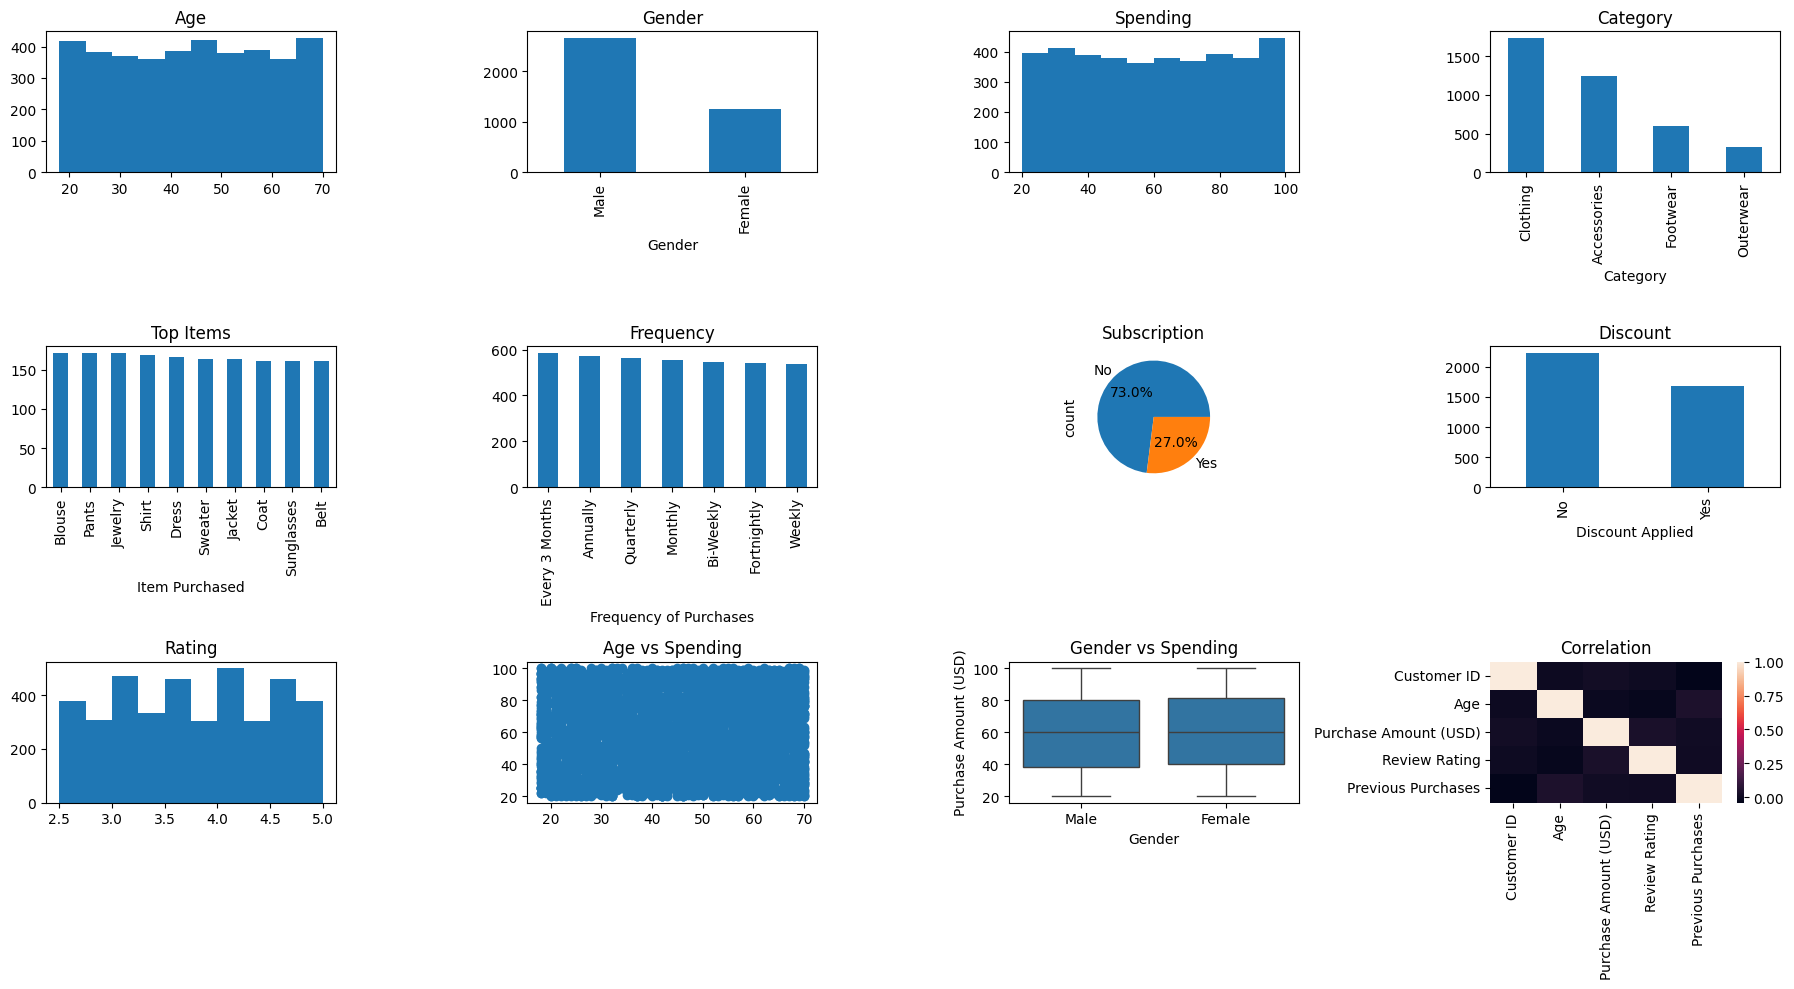

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(18, 10))

axes[0,0].hist(df['Age'])
axes[0,0].set_title("Age")

df['Gender'].value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Gender")

axes[0,2].hist(df['Purchase Amount (USD)'])
axes[0,2].set_title("Spending")

df['Category'].value_counts().plot(kind='bar', ax=axes[0,3])
axes[0,3].set_title("Category")

df['Item Purchased'].value_counts().head(10).plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Top Items")

df['Frequency of Purchases'].value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title("Frequency")

df['Subscription Status'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1,2])
axes[1,2].set_title("Subscription")

df['Discount Applied'].value_counts().plot(kind='bar', ax=axes[1,3])
axes[1,3].set_title("Discount")

axes[2,0].hist(df['Review Rating'])
axes[2,0].set_title("Rating")

axes[2,1].scatter(df['Age'], df['Purchase Amount (USD)'])
axes[2,1].set_title("Age vs Spending")

sns.boxplot(x=df['Gender'], y=df['Purchase Amount (USD)'], ax=axes[2,2])
axes[2,2].set_title("Gender vs Spending")

sns.heatmap(df.corr(numeric_only=True), ax=axes[2,3])
axes[2,3].set_title("Correlation")

plt.tight_layout()
plt.show()

##4.1 Biểu đồ cho thấy sở thích mua sắm khác nhau giữa nam và nữ

Biểu đồ cho thấy sở thích mua sắm khác nhau giữa nam và nữ, trong đó nữ giới thể hiện sự quan tâm đa dạng đến cả quần áo và phụ kiện, còn nam giới thường mua nhiều loại quần áo như áo sơ mi và áo khoác hơn nhưng ít mua phụ kiện và giày dép. Hiểu được những sở thích này có thể giúp điều chỉnh hàng tồn kho và các chiến dịch tiếp thị sao cho phù hợp hơn với thói quen mua sắm của từng giới.

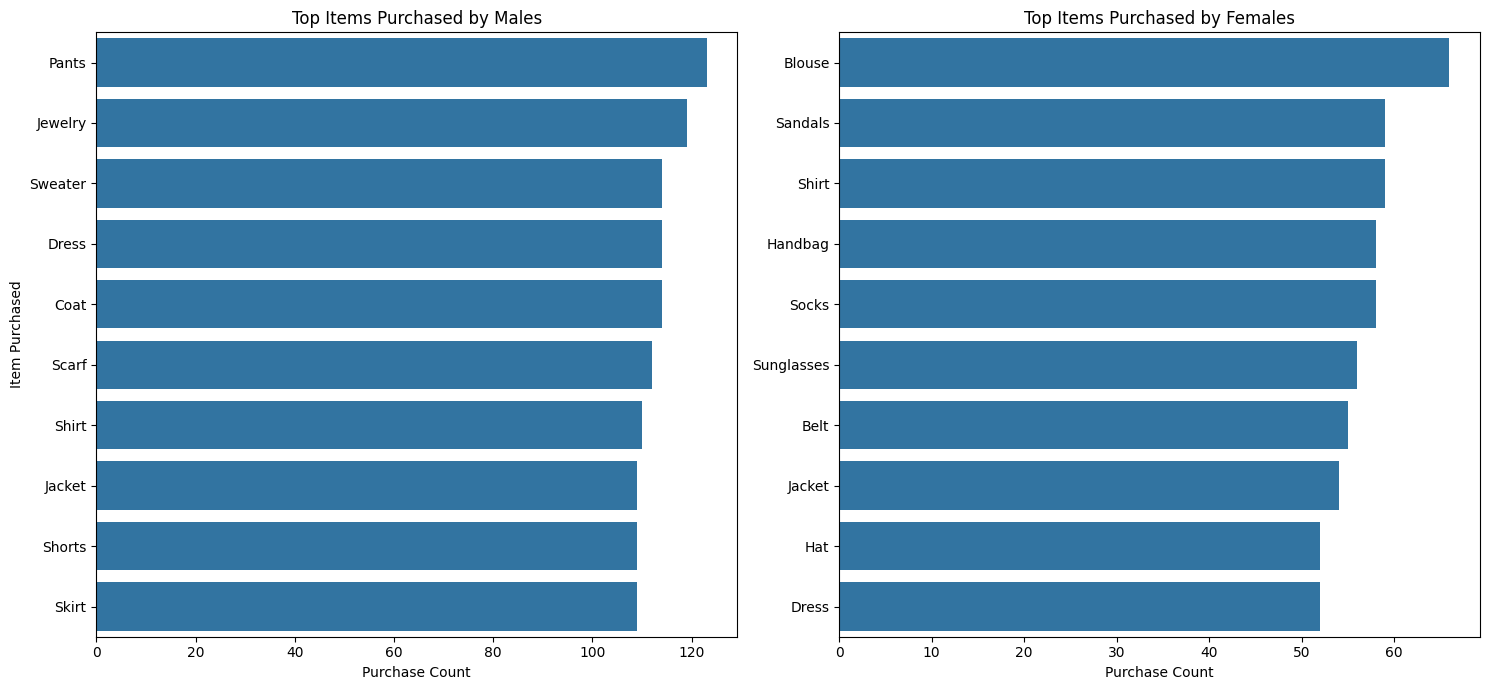

In [ ]:
##10 sản phẩm hàng đầu theo giới tính
N = 10

# Lọc và đếm số mặt hàng được mua bởi từng giới tính.
items_by_gender = df.groupby(['Gender', 'Item Purchased']).size().reset_index(name='Count')

# Sắp xếp và chọn ra N mục hàng đầu cho mỗi giới tính.
top_items_male = items_by_gender[items_by_gender['Gender'] == 'Male'].sort_values(by='Count', ascending=False).head(N)
top_items_female = items_by_gender[items_by_gender['Gender'] == 'Female'].sort_values(by='Count', ascending=False).head(N)

# Plotting
plt.figure(figsize=(15, 7))

# Plot for Male
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
sns.barplot(data=top_items_male, x='Count', y='Item Purchased')
plt.title('Top Items Purchased by Males')
plt.xlabel('Purchase Count')
plt.ylabel('Item Purchased')

# Plot for Female
plt.subplot(1, 2, 2)  # 1 row, 2 columns, 2nd subplot
sns.barplot(data=top_items_female, x='Count', y='Item Purchased')
plt.title('Top Items Purchased by Females')
plt.xlabel('Purchase Count')
plt.ylabel('')

plt.tight_layout()
plt.show()

###5. Kiểm tra outlier

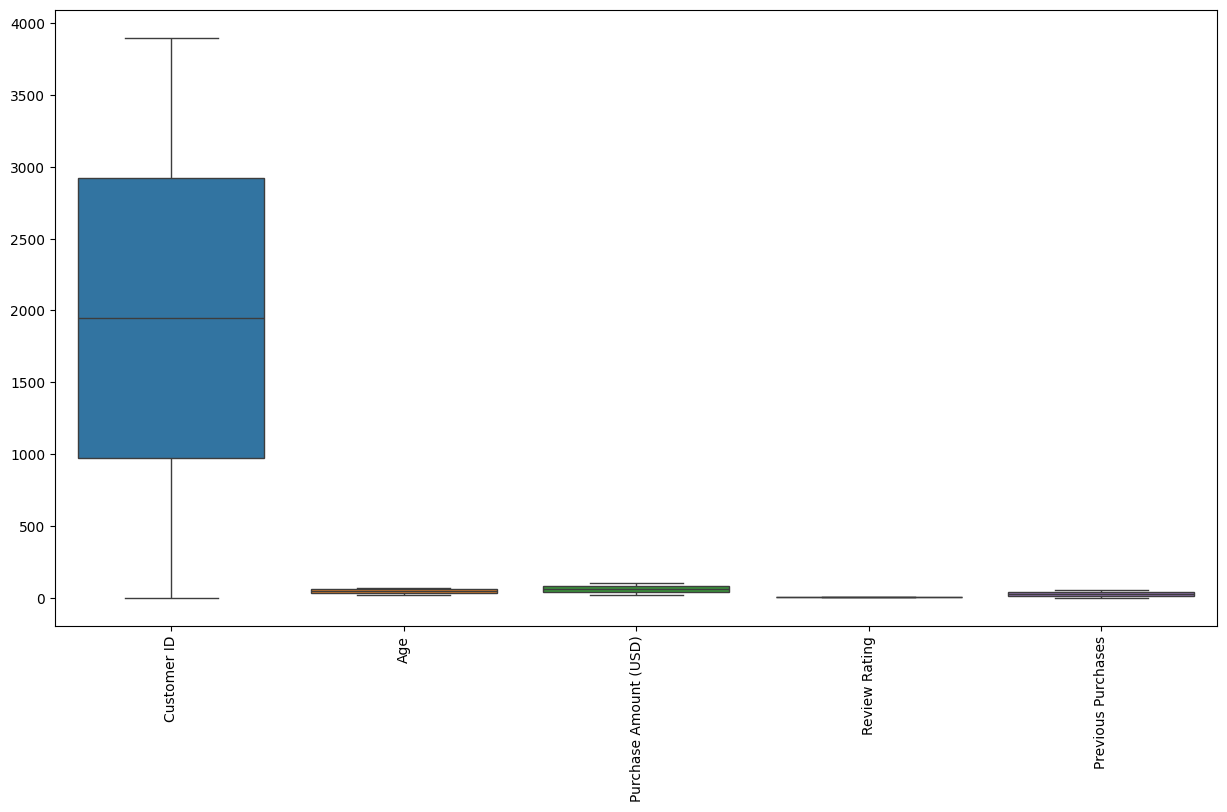

In [ ]:
plt.figure(figsize=(15,8))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

## 5.2 Loại bỏ các hàng trùng lặp

In [ ]:
df.drop_duplicates(inplace=True)

##6. One-Hot Encoding cho các biến phân loại
gồm các cột sau: `Gender`, `Category`, `Location`, `Season`, `Subscription Status`, `Payment Method`, `Shipping Type`, và `Frequency of Purchases`.

Mỗi giá trị duy nhất trong các cột phân loại này đã được chuyển đổi thành một cột nhị phân riêng biệt (0 hoặc 1). Điều này giúp mô hình có thể hiểu và xử lý các đặc trưng phân loại một cách hiệu quả mà không ngụ ý bất kỳ mối quan hệ thứ tự nào giữa các giá trị.

Kết quả là một ma trận thưa (`Custome_hot`) với kích thước `(3900, 81)`, cho thấy tổng cộng 81 cột mới đã được tạo ra từ 8 biến phân loại ban đầu, đại diện cho các đặc trưng mới được mã hóa.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ["Gender","Category","Location","Season",
                    "Subscription Status","Payment Method",
                    "Shipping Type","Frequency of Purchases"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [ ]:
X_cat = encoder.fit_transform(df[categorical_cols])

X_cat = pd.DataFrame(
    X_cat,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=df.index
)
X_cat

,Gender_Female,Gender_Male,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Location_Alabama,Location_Alaska,Location_Arizona,Location_Arkansas,...,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3896,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3897,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3898,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 7. Chuẩn hóa các biến số

Sau khi tách các biến phân loại để One-Hot, các biến số còn lại được chuẩn hóa bằng **StandardScaler**.  
Bước này giúp các đặc trưng có cùng thang đo, từ đó hỗ trợ K-mean, Hierarchical Clustering học ổn định hơn.

In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
X_num = df[numerical_cols]

scaler = StandardScaler()
X_scaled_num = scaler.fit_transform(X_num)

X_scaled_num_df = pd.DataFrame(X_scaled_num, columns=numerical_cols, index=df.index)

X_preprocessed = pd.concat([X_scaled_num_df, X_cat], axis=1)
X_preprocessed

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Gender_Female,Gender_Male,Category_Accessories,Category_Clothing,Category_Footwear,...,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,-1.731607,0.718913,-0.285629,-0.907584,-0.785831,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-1.730719,-1.648629,0.178852,-0.907584,-1.616552,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-1.729830,0.390088,0.558882,-0.907584,-0.162789,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-1.728942,-1.517099,1.276716,-0.349027,1.637107,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.728054,0.061263,-0.454531,-1.466141,0.391025,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,1.728054,-0.267563,-1.341267,0.628448,0.460252,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3896,1.728942,0.521618,-0.454531,1.047366,1.083293,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3897,1.729830,0.127028,-1.130139,-1.186862,-0.093563,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3898,1.730719,-0.004502,0.727784,0.069891,-0.093563,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


##8. Đánh giá mô hình

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
import pandas as pd

results = []

K_range = [2, 3, 4, 5]

for k in K_range:

    # KMeans
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_preprocessed)

    dbi_kmeans = davies_bouldin_score(X_preprocessed, kmeans_labels)
    chi_kmeans = calinski_harabasz_score(X_preprocessed, kmeans_labels)

    results.append(["KMeans", k, dbi_kmeans, chi_kmeans])


    # Hierarchical
    hc = AgglomerativeClustering(n_clusters=k)
    hc_labels = hc.fit_predict(X_preprocessed)

    dbi_hc = davies_bouldin_score(X_preprocessed, hc_labels)
    chi_hc = calinski_harabasz_score(X_preprocessed, hc_labels)

    results.append(["Hierarchical", k, dbi_hc, chi_hc])


# Tạo bảng
df_results = pd.DataFrame(results, columns=["Model", "K", "DBI", "CHI"])

df_results

,Model,K,DBI,CHI
0,KMeans,2,2.648287,471.032115
1,Hierarchical,2,2.694945,458.156870
2,KMeans,3,3.077585,362.900093
3,Hierarchical,3,3.322727,352.454848
4,KMeans,4,2.856806,299.310445
5,Hierarchical,4,3.219991,283.879419
6,KMeans,5,3.037724,260.183121
7,Hierarchical,5,3.557520,236.768814


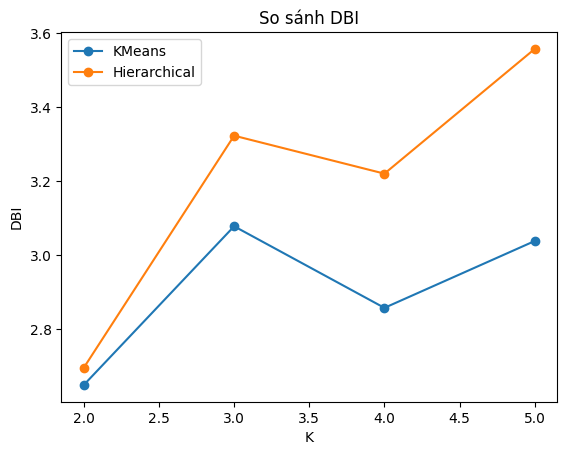

In [ ]:
import matplotlib.pyplot as plt

for model in df_results["Model"].unique():
    subset = df_results[df_results["Model"] == model]
    plt.plot(subset["K"], subset["DBI"], marker='o', label=model)

plt.title("So sánh DBI")
plt.xlabel("K")
plt.ylabel("DBI")
plt.legend()
plt.show()

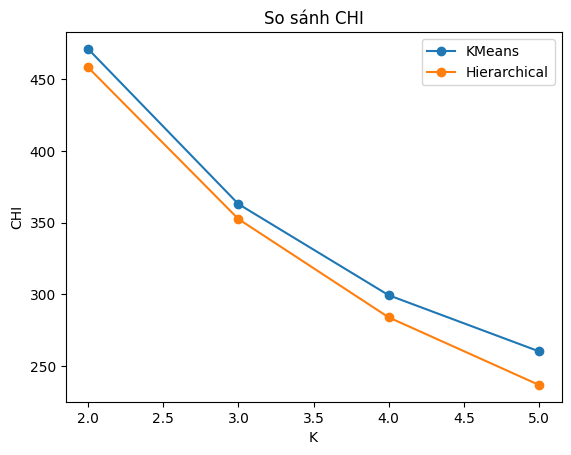

In [ ]:
for model in df_results["Model"].unique():
    subset = df_results[df_results["Model"] == model]
    plt.plot(subset["K"], subset["CHI"], marker='o', label=model)

plt.title("So sánh CHI")
plt.xlabel("K")
plt.ylabel("CHI")
plt.legend()
plt.show()